# Mechanistic analysis of LoRA and DoRA weight updates (remote adapters)

For a PyTorch linear weight, $W \in \mathbb{R}^{out \times in}$, each row is decomposed into magnitude and direction:

$$m_i = \lVert W_{i,:} \rVert_2, \qquad d_{i,:} = W_{i,:}/m_i.$$

The primary mechanistic quantities are:

$$\Delta D = \operatorname{mean}_i\left[1-\cos(d_i,d_{0,i})\right],$$

$$\Delta M_{paper} = \operatorname{mean}_i |m_i-m_{0,i}|,$$

$$\Delta M_{rel} = \frac{\lVert m-m_0\rVert_2}{\lVert m_0\rVert_2}.$$

LoRA/QLoRA uses $W' = W_0+sBA$. DoRA/QDoRA rescales each row
of $W_0+sBA$ to the learned magnitude vector. The notebook reports both the
relative low-rank coefficient update $\lVert sBA\rVert_F/\lVert W_0\rVert_F$
and the relative effective update $\lVert W'-W_0\rVert_F/\lVert W_0\rVert_F$.


## 1. Setup and analysis configuration

In [4]:
import json
import math
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch
import torch.nn.functional as F
import yaml
from dotenv import load_dotenv
from huggingface_hub import HfApi
from IPython.display import display
from matplotlib.lines import Line2D

load_dotenv()

HF_ENDPOINT = "https://huggingface.co".rstrip("/")
HF_TOKEN = os.environ.get("HF_TOKEN")

REPO_ID = "anon-review-12345/dora-reproducibility-study"
REVISION = "main"

BASE_MODEL_ID_OVERRIDE = None

RUNS = {
    "lora-match-seed42":  {"repo_dir": "lora-lr-match/seed-42", "method": "LoRA lr-match", "seed": 42},
    "lora-match-seed43":  {"repo_dir": "lora-lr-match/seed-43", "method": "LoRA lr-match", "seed": 43},
    "dora-seed42":        {"repo_dir": "dora/seed-42",          "method": "DoRA",         "seed": 42},
    "dora-seed43":        {"repo_dir": "dora/seed-43",          "method": "DoRA",         "seed": 43},
    "qdora-seed42-fp32":  {"repo_dir": "qdora-fp32/seed-42",    "method": "QDoRA-fp32",   "seed": 42},
    "qdora-seed43-fp32":  {"repo_dir": "qdora-fp32/seed-43",    "method": "QDoRA-fp32",   "seed": 43},
    "qlora-seed42":       {"repo_dir": "qlora/seed-42",         "method": "QLoRA",        "seed": 42},
    "qlora-seed43":       {"repo_dir": "qlora/seed-43",         "method": "QLoRA",        "seed": 43},
}

PAPER_TARGET_MODULES = ["q_proj", "v_proj"]
EXTENDED_TARGET_MODULES = [
    "q_proj", "k_proj", "v_proj", "o_proj",
    "up_proj", "down_proj", "gate_proj",
]
TARGET_MODULES = list(dict.fromkeys(PAPER_TARGET_MODULES + EXTENDED_TARGET_MODULES))
ATTENTION_MODULES = {"q_proj", "k_proj", "v_proj", "o_proj"}
LAYERS = list(range(6))
CHECKPOINT_FRACTIONS = (0.25, 0.50, 0.75, 1.00)

PAPER_M_METRIC = "delta_magnitude_paper"
NORMALIZED_M_METRIC = "delta_magnitude_rel"
EPS = 1e-12
COMPUTE_QUANTIZATION_EFFECTS = True

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_ORDER = list(RUNS)


def display_name(run_id):
    info = RUNS[run_id]
    seed = f"seed {info['seed']}" if info["seed"] is not None else run_id
    return f"{info['method']} ({seed})"

## 2. Remote file access


In [5]:
SESSION = requests.Session()
if HF_TOKEN:
    SESSION.headers["Authorization"] = f"Bearer {HF_TOKEN}"

REQUEST_TIMEOUT = 60
REQUEST_RETRIES = 3


def http_get(repo_id, path, revision=REVISION, headers=None):
    url = f"{HF_ENDPOINT}/{repo_id}/resolve/{revision}/{path}"
    last_error = None
    for _ in range(REQUEST_RETRIES):
        try:
            response = SESSION.get(url, headers=headers, timeout=REQUEST_TIMEOUT)
            response.raise_for_status()
            return response
        except requests.RequestException as error:
            last_error = error
    raise RuntimeError(f"GET failed after {REQUEST_RETRIES} attempts: {url}") from last_error


def read_remote_json(repo_id, path, revision=REVISION):
    return json.loads(http_get(repo_id, path, revision).text)


def read_remote_yaml(repo_id, path, revision=REVISION):
    return yaml.safe_load(http_get(repo_id, path, revision).text)


SAFETENSORS_DTYPES = {
    "F64": torch.float64, "F32": torch.float32, "F16": torch.float16,
    "BF16": torch.bfloat16, "I64": torch.int64, "I32": torch.int32,
    "I16": torch.int16, "I8": torch.int8, "U8": torch.uint8, "BOOL": torch.bool,
}


class RemoteSafetensors:
    """Random access into a safetensors file on the Hub, via HTTP range requests.

    Only the header and the byte ranges of the tensors actually requested are
    transferred; nothing is written to disk.
    """

    def __init__(self, repo_id, path, revision=REVISION):
        self.repo_id = repo_id
        self.path = path
        self.revision = revision
        header_length = int.from_bytes(self._read(0, 8), "little")
        self.header = json.loads(self._read(8, 8 + header_length))
        self.header.pop("__metadata__", None)
        self.data_start = 8 + header_length

    def _read(self, start, end):
        response = http_get(
            self.repo_id, self.path, self.revision,
            headers={"Range": f"bytes={start}-{end - 1}"},
        )
        if response.status_code != 206:
            raise RuntimeError(
                f"Server ignored the range request for {self.repo_id}/{self.path}"
            )
        return response.content

    def keys(self):
        return self.header.keys()

    def get_tensor(self, name):
        entry = self.header[name]
        start, end = entry["data_offsets"]
        buffer = bytearray(self._read(self.data_start + start, self.data_start + end))
        tensor = torch.frombuffer(buffer, dtype=SAFETENSORS_DTYPES[entry["dtype"]])
        return tensor.reshape(entry["shape"])


REMOTE_FILE_CACHE = {}


def remote_safetensors(repo_id, path, revision=REVISION):
    key = (repo_id, path, revision)
    if key not in REMOTE_FILE_CACHE:
        REMOTE_FILE_CACHE[key] = RemoteSafetensors(repo_id, path, revision)
    return REMOTE_FILE_CACHE[key]


HF_API = HfApi(token=HF_TOKEN)

try:
    REPO_FILES = set(HF_API.list_repo_files(REPO_ID, revision=REVISION))
except Exception as error:
    raise RuntimeError(
        f"Could not list {REPO_ID}@{REVISION}. Gated repositories need a valid "
        "HF_TOKEN in the environment or in .env."
    ) from error

print(f"{REPO_ID}@{REVISION}: {len(REPO_FILES):,} files listed (no download yet)")

anon-review-12345/dora-reproducibility-study@main: 797 files listed (no download yet)


## 3. Run configuration and snapshot selection

In [6]:
SPECS = {}
SELECTED_SNAPSHOTS = {}

for run_id, run_info in RUNS.items():
    repo_dir = run_info["repo_dir"]

    config = read_remote_yaml(REPO_ID, f"{repo_dir}/resolved_config.yaml")
    model = config.get("model", {}) or {}
    quantization = config.get("quantization", {}) or {}
    SPECS[run_id] = {
        "model_id": BASE_MODEL_ID_OVERRIDE or model.get("id"),
        "revision": model.get("revision") or "main",
        "dtype": str(model.get("torch_dtype", model.get("dtype", "auto"))),
        "quantized": bool(quantization.get("enabled", False)),
        "bits": int(quantization.get("bits", 4) or 4),
        "quant_type": quantization.get("quant_type", "nf4") or "nf4",
        "double_quant": bool(quantization.get("double_quant", True)),
    }

    # Every snapshot directory of this run, ordered by training step.
    prefix = f"{repo_dir}/analysis_snapshots/"
    names = sorted({
        path[len(prefix):].split("/")[0]
        for path in REPO_FILES if path.startswith(prefix)
    })
    snapshots = []
    for name in names:
        snapshot_dir = prefix + name
        if f"{snapshot_dir}/adapter_model.safetensors" not in REPO_FILES:
            continue
        metadata_path = f"{snapshot_dir}/snapshot_metadata.json"
        metadata = (
            read_remote_json(REPO_ID, metadata_path)
            if metadata_path in REPO_FILES else {}
        )
        if metadata.get("step") is not None:
            step = int(metadata["step"])
        else:
            match = re.search(r"step_(\d+)", name)
            step = int(match.group(1)) if match else 0
        snapshots.append({
            "name": name,
            "repo_dir": snapshot_dir,
            "label": str(metadata.get("label", name)),
            "step": step,
        })

    if not snapshots:
        raise FileNotFoundError(f"No analysis snapshots under {repo_dir} in {REPO_ID}")
    snapshots.sort(key=lambda snapshot: (snapshot["step"], snapshot["name"]))

    explicit_final = [s for s in snapshots if s["label"].lower() == "final"]
    final_snapshot = max(explicit_final or snapshots, key=lambda s: s["step"])

    selected = []
    for fraction in CHECKPOINT_FRACTIONS:
        if np.isclose(fraction, 1.0):
            selected.append(final_snapshot)
            continue

        expected_label = f"fraction_{fraction:g}"
        labelled = [s for s in snapshots if s["label"] == expected_label]
        candidates = labelled or [s for s in snapshots if s is not final_snapshot]
        target_step = fraction * final_snapshot["step"]
        selected.append(min(candidates, key=lambda s: abs(s["step"] - target_step)))
    SELECTED_SNAPSHOTS[run_id] = selected

    specification = SPECS[run_id]
    base_kind = (
        f"{specification['bits']}-bit {specification['quant_type']}"
        if specification["quantized"] else "dense"
    )
    steps = ", ".join(
        f"{fraction:.0%}={snapshot['step']}"
        for fraction, snapshot in zip(CHECKPOINT_FRACTIONS, selected)
    )
    print(f"{run_id:>18} | {specification['model_id']} ({base_kind}) | {steps}")
    if len({id(snapshot) for snapshot in selected}) != len(CHECKPOINT_FRACTIONS):
        print(f"{'':>18} | WARNING: one snapshot was selected for several fractions")

 lora-match-seed42 | meta-llama/Meta-Llama-3-8B (dense) | 25%=7989, 50%=15978, 75%=23967, 100%=31956
 lora-match-seed43 | meta-llama/Meta-Llama-3-8B (dense) | 25%=7989, 50%=15978, 75%=23967, 100%=31956
       dora-seed42 | meta-llama/Meta-Llama-3-8B (dense) | 25%=7989, 50%=15978, 75%=23967, 100%=31956
       dora-seed43 | meta-llama/Meta-Llama-3-8B (dense) | 25%=7989, 50%=15978, 75%=23967, 100%=31956
 qdora-seed42-fp32 | meta-llama/Meta-Llama-3-8B (4-bit nf4) | 25%=7989, 50%=15978, 75%=23967, 100%=31956
 qdora-seed43-fp32 | meta-llama/Meta-Llama-3-8B (4-bit nf4) | 25%=7989, 50%=15978, 75%=23967, 100%=31956
      qlora-seed42 | meta-llama/Meta-Llama-3-8B (4-bit nf4) | 25%=7989, 50%=15978, 75%=23967, 100%=31956
      qlora-seed43 | meta-llama/Meta-Llama-3-8B (4-bit nf4) | 25%=7989, 50%=15978, 75%=23967, 100%=31956


## 4. Base weights



In [7]:
# Which safetensors shard holds which tensor, per base model.
WEIGHT_MAPS = {}
for specification in SPECS.values():
    model_key = (specification["model_id"], specification["revision"])
    if model_key in WEIGHT_MAPS:
        continue
    model_id, revision = model_key
    files = set(HF_API.list_repo_files(model_id, revision=revision))
    if "model.safetensors.index.json" in files:
        index = read_remote_json(model_id, "model.safetensors.index.json", revision)
        WEIGHT_MAPS[model_key] = index["weight_map"]
    elif "model.safetensors" in files:
        WEIGHT_MAPS[model_key] = None  # single-file checkpoint
    else:
        raise FileNotFoundError(f"No safetensors weights found in {model_id}@{revision}")

DTYPE_ALIASES = {
    "bf16": torch.bfloat16, "bfloat16": torch.bfloat16,
    "fp16": torch.float16, "float16": torch.float16, "half": torch.float16,
    "fp32": torch.float32, "float32": torch.float32,
}

BASE_WEIGHT_CACHE = {}


def load_base_weight(specification, layer, target_module, force_dense=False):
    """One projection weight of the base model, as this run's adapter saw it."""
    variant = "dense" if force_dense or not specification["quantized"] else (
        specification["dtype"], f"{specification['bits']}bit",
        specification["quant_type"], specification["double_quant"],
    )
    key = (
        specification["model_id"], specification["revision"], variant,
        target_module, layer,
    )
    if key in BASE_WEIGHT_CACHE:
        return BASE_WEIGHT_CACHE[key]

    block = "self_attn" if target_module in ATTENTION_MODULES else "mlp"
    tensor_name = f"model.layers.{layer}.{block}.{target_module}.weight"
    weight_map = WEIGHT_MAPS[(specification["model_id"], specification["revision"])]
    shard = "model.safetensors" if weight_map is None else weight_map[tensor_name]
    weight = remote_safetensors(
        specification["model_id"], shard, specification["revision"]
    ).get_tensor(tensor_name)

    # A missing alias means torch_dtype: auto, i.e. keep the checkpoint dtype.
    dtype = DTYPE_ALIASES.get(specification["dtype"].lower())
    if dtype is not None:
        weight = weight.to(dtype)

    if specification["quantized"] and not force_dense:
        if specification["bits"] != 4:
            raise NotImplementedError(
                f"Only 4-bit bases are reproduced here; this run used {specification['bits']}-bit."
            )
        import bitsandbytes.functional as bnb_functional

        device = "cuda" if torch.cuda.is_available() else "cpu"
        quantized, quant_state = bnb_functional.quantize_4bit(
            weight.to(device).contiguous(),
            blocksize=64,
            compress_statistics=specification["double_quant"],
            quant_type=specification["quant_type"],
        )
        weight = bnb_functional.dequantize_4bit(quantized, quant_state).to(weight.dtype).cpu()

    BASE_WEIGHT_CACHE[key] = weight
    return weight

## 5. Mechanistic metrics by run, checkpoint, layer, and module

`mech_layer_metrics.csv` is the canonical analysis dataset.

In [8]:
def decompose_weight(weight):
    weight = weight.float()
    magnitude = torch.linalg.vector_norm(weight, dim=1)
    direction = weight / magnitude.clamp_min(EPS).unsqueeze(1)
    return magnitude, direction


def delta_direction(current_direction, reference_direction):
    cosine = F.cosine_similarity(
        current_direction.float(), reference_direction.float(), dim=1, eps=EPS
    )
    return float((1.0 - cosine.clamp(-1.0, 1.0)).mean())


def magnitude_metrics(current_magnitude, reference_magnitude):
    difference = current_magnitude.float() - reference_magnitude.float()
    return {
        "delta_magnitude_paper": float(difference.abs().mean()),
        "delta_magnitude_rel": float(
            torch.linalg.vector_norm(difference)
            / torch.linalg.vector_norm(reference_magnitude.float()).clamp_min(EPS)
        ),
    }


rows = []
for run_id, run_info in RUNS.items():
    specification = SPECS[run_id]
    with_dense = specification["quantized"] and COMPUTE_QUANTIZATION_EFFECTS

    for checkpoint_fraction, snapshot in zip(
        CHECKPOINT_FRACTIONS, SELECTED_SNAPSHOTS[run_id]
    ):
        adapter_config = read_remote_json(
            REPO_ID, f"{snapshot['repo_dir']}/adapter_config.json"
        )
        tensors = remote_safetensors(
            REPO_ID, f"{snapshot['repo_dir']}/adapter_model.safetensors"
        )

        rank = float(adapter_config["r"])
        alpha = float(adapter_config["lora_alpha"])
        scaling = (
            alpha / math.sqrt(rank) if adapter_config.get("use_rslora", False)
            else alpha / rank
        )

        # Restrict the analysis to projection families this adapter trained.
        configured = adapter_config.get("target_modules", TARGET_MODULES)
        if isinstance(configured, str):
            snapshot_target_modules = [
                module for module in TARGET_MODULES
                if re.search(configured, module) is not None
            ]
        else:
            snapshot_target_modules = [
                module for module in TARGET_MODULES if module in set(configured)
            ]

        for target_module in snapshot_target_modules:
            for layer in LAYERS:
                base_weight = load_base_weight(
                    specification, layer, target_module
                ).float()

                block = (
                    f"self_attn.{target_module}" if target_module in ATTENTION_MODULES
                    else f"mlp.{target_module}"
                )
                prefix = f"base_model.model.model.layers.{layer}.{block}"
                lora_a = tensors.get_tensor(f"{prefix}.lora_A.weight").float()
                lora_b = tensors.get_tensor(f"{prefix}.lora_B.weight").float()

                # W' = W0 + sBA, with each row rescaled to the learned magnitude for DoRA.
                coefficient_update = scaling * (lora_b @ lora_a)
                effective_weight = base_weight + coefficient_update
                if adapter_config.get("use_dora", False):
                    magnitude_key = next(
                        key for key in tensors.keys()
                        if key.startswith(f"{prefix}.lora_magnitude_vector")
                    )
                    magnitude = tensors.get_tensor(magnitude_key).float().reshape(-1, 1)
                    row_norm = torch.linalg.vector_norm(
                        effective_weight, dim=1
                    ).clamp_min(EPS).reshape(-1, 1)
                    effective_weight = (magnitude / row_norm) * effective_weight

                base_magnitude, base_direction = decompose_weight(base_weight)
                current_magnitude, current_direction = decompose_weight(effective_weight)
                denominator = torch.linalg.norm(base_weight).clamp_min(EPS)

                row = {
                    "run_id": run_id,
                    "run": display_name(run_id),
                    "method": run_info["method"],
                    "seed": run_info["seed"],
                    "snapshot": snapshot["name"],
                    "step": snapshot["step"],
                    "checkpoint_fraction": checkpoint_fraction,
                    "layer": layer,
                    "target_module": target_module,
                    "quantized_base": specification["quantized"],
                    "delta_direction": delta_direction(current_direction, base_direction),
                    "coefficient_update_rel": float(
                        torch.linalg.norm(coefficient_update) / denominator
                    ),
                    "effective_weight_update_rel": float(
                        torch.linalg.norm(effective_weight - base_weight) / denominator
                    ),
                }
                row.update(magnitude_metrics(current_magnitude, base_magnitude))

                if with_dense:
                    dense_base_weight = load_base_weight(
                        specification, layer, target_module, force_dense=True
                    ).float()
                    dense_magnitude, dense_direction = decompose_weight(dense_base_weight)
                    row["quant_delta_direction"] = delta_direction(
                        base_direction, dense_direction
                    )
                    row["total_delta_direction"] = delta_direction(
                        current_direction, dense_direction
                    )
                    row.update({
                        f"quant_{key}": value
                        for key, value in magnitude_metrics(
                            base_magnitude, dense_magnitude
                        ).items()
                    })
                    row.update({
                        f"total_{key}": value
                        for key, value in magnitude_metrics(
                            current_magnitude, dense_magnitude
                        ).items()
                    })
                rows.append(row)

        print(
            f"[{run_id}] fraction {checkpoint_fraction:>4.2f} | {snapshot['name']} | "
            f"{len(snapshot_target_modules)} modules x {len(LAYERS)} layers"
        )

weight_df = pd.DataFrame(rows).sort_values(
    ["run_id", "checkpoint_fraction", "target_module", "layer"]
).reset_index(drop=True)

layer_metric_columns = [
    "run_id", "run", "method", "seed", "snapshot", "step",
    "checkpoint_fraction", "layer", "target_module", "quantized_base",
    "delta_direction", "delta_magnitude_paper", "delta_magnitude_rel",
    "coefficient_update_rel", "effective_weight_update_rel",
] + [
    column for column in weight_df.columns
    if column.startswith("quant_") or column.startswith("total_")
]
layer_metric_columns = list(dict.fromkeys(layer_metric_columns))
weight_df[layer_metric_columns].to_csv(
    OUTPUT_DIR / "mech_layer_metrics.csv", index=False
)

print(f"\nMechanistic dataset: {len(weight_df):,} rows")
print(f"Exported: {OUTPUT_DIR / 'mech_layer_metrics.csv'}")

[lora-match-seed42] fraction 0.25 | fraction_0.25_step_7989 | 5 modules x 6 layers
[lora-match-seed42] fraction 0.50 | fraction_0.5_step_15978 | 5 modules x 6 layers
[lora-match-seed42] fraction 0.75 | fraction_0.75_step_23967 | 5 modules x 6 layers
[lora-match-seed42] fraction 1.00 | final_step_31956 | 5 modules x 6 layers
[lora-match-seed43] fraction 0.25 | fraction_0.25_step_7989 | 5 modules x 6 layers
[lora-match-seed43] fraction 0.50 | fraction_0.5_step_15978 | 5 modules x 6 layers
[lora-match-seed43] fraction 0.75 | fraction_0.75_step_23967 | 5 modules x 6 layers
[lora-match-seed43] fraction 1.00 | final_step_31956 | 5 modules x 6 layers
[dora-seed42] fraction 0.25 | fraction_0.25_step_7989 | 5 modules x 6 layers
[dora-seed42] fraction 0.50 | fraction_0.5_step_15978 | 5 modules x 6 layers
[dora-seed42] fraction 0.75 | fraction_0.75_step_23967 | 5 modules x 6 layers
[dora-seed42] fraction 1.00 | final_step_31956 | 5 modules x 6 layers
[dora-seed43] fraction 0.25 | fraction_0.25_st

## 6. Regression coefficients

The regression table contains two complementary relationships:
- ΔM on ΔD across layer × checkpoint points for each run and module.
- Relative low-rank coefficient update on checkpoint fraction for each
  run, module, and layer.

Q/V rows include both the paper and normalized ΔM definitions. Extended
modules use the normalized definition for cross-scale comparison.

In [9]:
def fit_relation(frame, predictor, outcome):
    clean = frame[[predictor, outcome]].dropna()
    x = clean[predictor].to_numpy(dtype=float)
    y = clean[outcome].to_numpy(dtype=float)
    if len(x) < 2 or np.allclose(x, x[0]):
        return np.nan, np.nan, np.nan, np.nan, len(x)

    slope, intercept = np.polyfit(x, y, 1)
    correlation = np.nan if np.allclose(y, y[0]) else np.corrcoef(x, y)[0, 1]
    r_squared = correlation ** 2 if np.isfinite(correlation) else np.nan
    return slope, intercept, correlation, r_squared, len(x)


regression_rows = []
for (run_id, run_name, method, seed, module), subset in weight_df.groupby(
    ["run_id", "run", "method", "seed", "target_module"], dropna=False
):
    metrics = (
        [PAPER_M_METRIC, NORMALIZED_M_METRIC]
        if module in PAPER_TARGET_MODULES
        else [NORMALIZED_M_METRIC]
    )
    for metric in metrics:
        slope, intercept, correlation, r_squared, n_points = fit_relation(
            subset, "delta_direction", metric
        )
        regression_rows.append({
            "relationship": "delta_m_vs_delta_d",
            "run_id": run_id,
            "run": run_name,
            "method": method,
            "seed": seed,
            "target_module": module,
            "layer": np.nan,
            "predictor": "delta_direction",
            "outcome": metric,
            "slope": slope,
            "intercept": intercept,
            "correlation": correlation,
            "r_squared": r_squared,
            "n_points": n_points,
        })

    for layer, layer_subset in subset.groupby("layer"):
        slope, intercept, correlation, r_squared, n_points = fit_relation(
            layer_subset, "checkpoint_fraction", "coefficient_update_rel"
        )
        regression_rows.append({
            "relationship": "coefficient_update_vs_checkpoint",
            "run_id": run_id,
            "run": run_name,
            "method": method,
            "seed": seed,
            "target_module": module,
            "layer": layer,
            "predictor": "checkpoint_fraction",
            "outcome": "coefficient_update_rel",
            "slope": slope,
            "intercept": intercept,
            "correlation": correlation,
            "r_squared": r_squared,
            "n_points": n_points,
        })

regression_df = pd.DataFrame(regression_rows)
regression_df.to_csv(OUTPUT_DIR / "mech_regression_results.csv", index=False)

primary_regression = regression_df[
    (regression_df["relationship"] == "delta_m_vs_delta_d")
    & (regression_df["target_module"].isin(PAPER_TARGET_MODULES))
    & (regression_df["outcome"] == PAPER_M_METRIC)
][[
    "run", "target_module", "slope", "intercept",
    "correlation", "r_squared", "n_points",
]]
display(primary_regression.round(5))
print(f"Exported: {OUTPUT_DIR / 'mech_regression_results.csv'}")

,run,target_module,slope,intercept,correlation,r_squared,n_points
14,DoRA (seed 42),q_proj,0.27119,0.00549,0.74484,0.55479,24
29,DoRA (seed 42),v_proj,0.12257,0.00569,0.68974,0.47573,24
51,DoRA (seed 43),q_proj,0.22712,0.00571,0.67521,0.45592,24
66,DoRA (seed 43),v_proj,0.12211,0.00566,0.68418,0.46810,24
88,LoRA lr-match (seed 42),q_proj,0.78513,0.00025,0.99407,0.98817,24
103,LoRA lr-match (seed 42),v_proj,0.36265,0.00124,0.95256,0.90736,24
125,LoRA lr-match (seed 43),q_proj,0.75710,0.00043,0.99299,0.98603,24
140,LoRA lr-match (seed 43),v_proj,0.36314,0.00126,0.95594,0.91382,24
162,QDoRA-fp32 (seed 42),q_proj,1.30468,0.00605,0.29349,0.08613,24
177,QDoRA-fp32 (seed 42),v_proj,0.66372,0.00593,0.37267,0.13889,24


Exported: outputs/mech_regression_results.csv


## 7. Paper-style ΔM–ΔD relationship

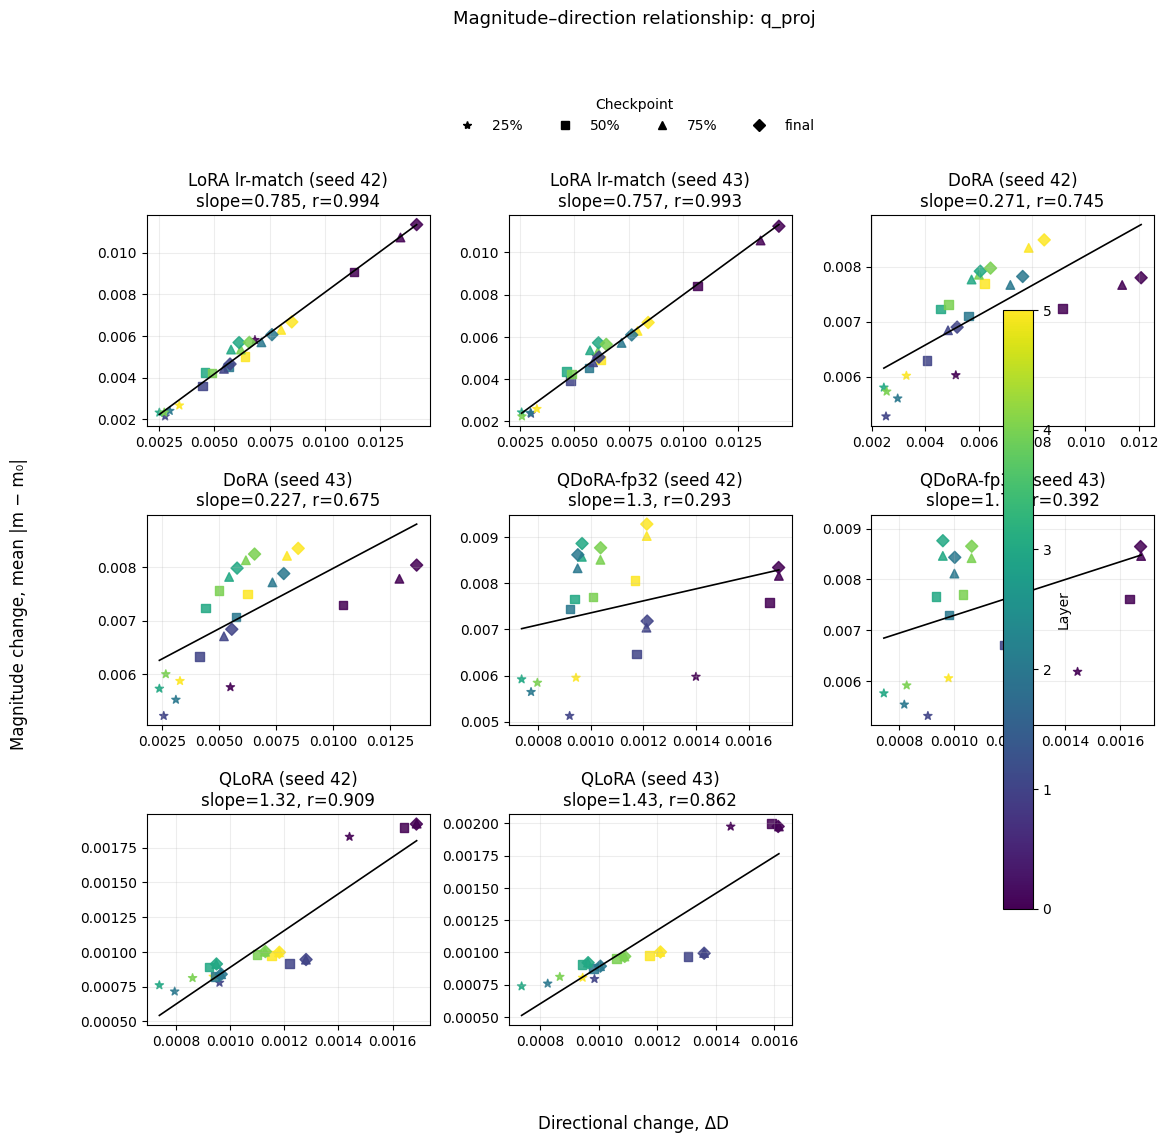

Exported: outputs/mech_delta_m_vs_delta_d_q_proj.pdf


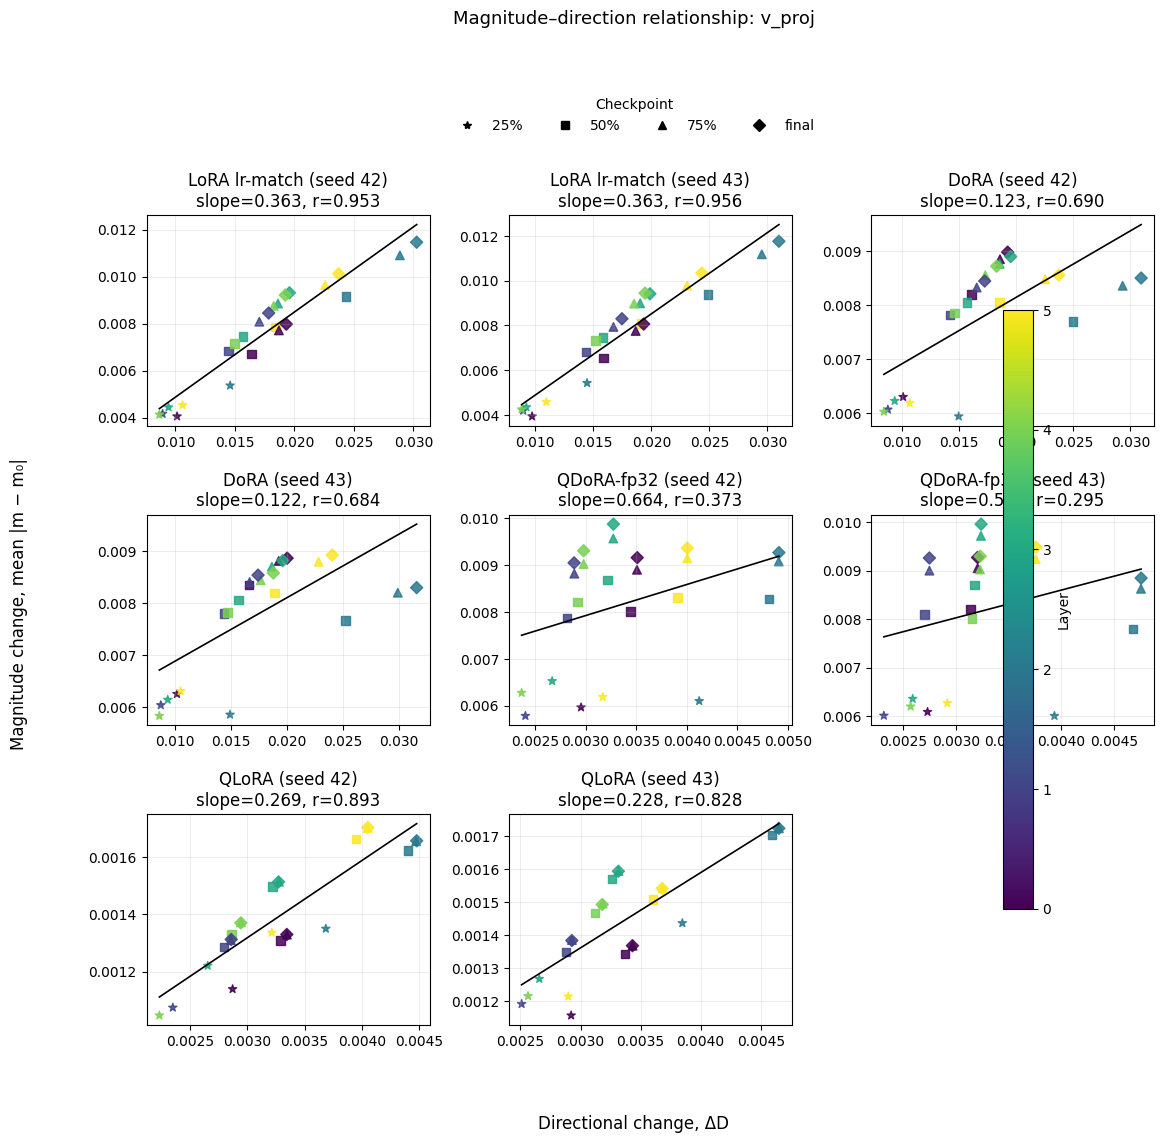

Exported: outputs/mech_delta_m_vs_delta_d_v_proj.pdf


In [10]:
CHECKPOINT_MARKERS = {0.25: "*", 0.50: "s", 0.75: "^", 1.00: "D"}
paper_df = weight_df[weight_df["target_module"].isin(PAPER_TARGET_MODULES)].copy()
plotted_runs = [run_id for run_id in RUN_ORDER if run_id in set(paper_df["run_id"])]
NCOLS = 3
NROWS = math.ceil(len(plotted_runs) / NCOLS)

for module in PAPER_TARGET_MODULES:
    fig, axes = plt.subplots(
        NROWS, NCOLS, figsize=(13, 3.6 * NROWS), squeeze=False,
        sharex=False, sharey=False,
    )
    color_norm = plt.Normalize(min(LAYERS), max(LAYERS))

    for axis, run_id in zip(axes.flat, plotted_runs):
        subset = paper_df[
            (paper_df["run_id"] == run_id)
            & (paper_df["target_module"] == module)
        ]
        for checkpoint, checkpoint_subset in subset.groupby("checkpoint_fraction"):
            axis.scatter(
                checkpoint_subset["delta_direction"],
                checkpoint_subset[PAPER_M_METRIC],
                c=checkpoint_subset["layer"],
                cmap="viridis",
                norm=color_norm,
                marker=CHECKPOINT_MARKERS[float(checkpoint)],
                s=38,
                alpha=0.85,
            )

        slope, intercept, correlation, _, _ = fit_relation(
            subset, "delta_direction", PAPER_M_METRIC
        )
        x_values = np.linspace(
            subset["delta_direction"].min(), subset["delta_direction"].max(), 100
        )
        axis.plot(x_values, slope * x_values + intercept, color="black", linewidth=1.2)
        axis.set_title(f"{display_name(run_id)}\nslope={slope:.3g}, r={correlation:.3f}")
        axis.grid(alpha=0.22)

    for axis in axes.flat[len(plotted_runs):]:
        axis.set_visible(False)

    marker_handles = [
        Line2D(
            [0], [0], color="black", marker=marker, linestyle="None",
            markersize=6, label=("final" if fraction == 1.0 else f"{fraction:.0%}"),
        )
        for fraction, marker in CHECKPOINT_MARKERS.items()
    ]
    fig.suptitle(f"Magnitude–direction relationship: {module}", y=1.05, fontsize=13)
    fig.legend(handles=marker_handles, title="Checkpoint", loc="upper center",
               bbox_to_anchor=(0.5, 0.98), ncol=4, frameon=False)
    scalar_map = plt.cm.ScalarMappable(norm=color_norm, cmap="viridis")
    fig.colorbar(scalar_map, ax=axes.ravel().tolist(), label="Layer", shrink=0.72)
    fig.supxlabel("Directional change, ΔD")
    fig.supylabel("Magnitude change, mean |m − m₀|")
    fig.subplots_adjust(top=0.86, hspace=0.42, wspace=0.28)

    output_path = OUTPUT_DIR / f"mech_delta_m_vs_delta_d_{module}.pdf"
    fig.savefig(output_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Exported: {output_path}")

## 8. ΔM through layers

Each panel preserves the physical run and shows how the paper ΔM metric changes
from layer 0 through layer 5 at every selected checkpoint.

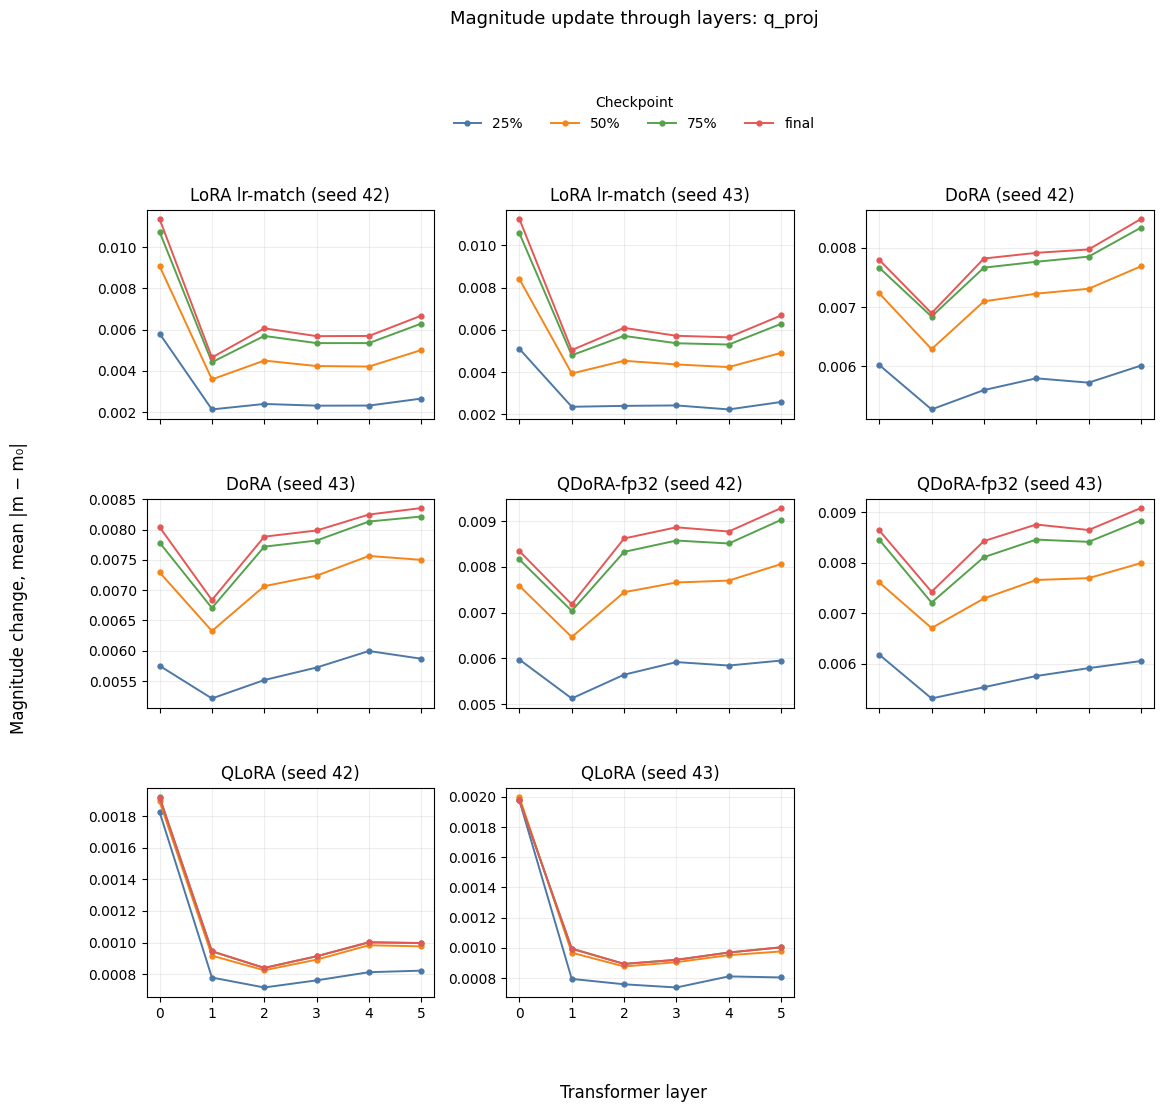

Exported: outputs/mech_delta_m_by_layer_q_proj.pdf


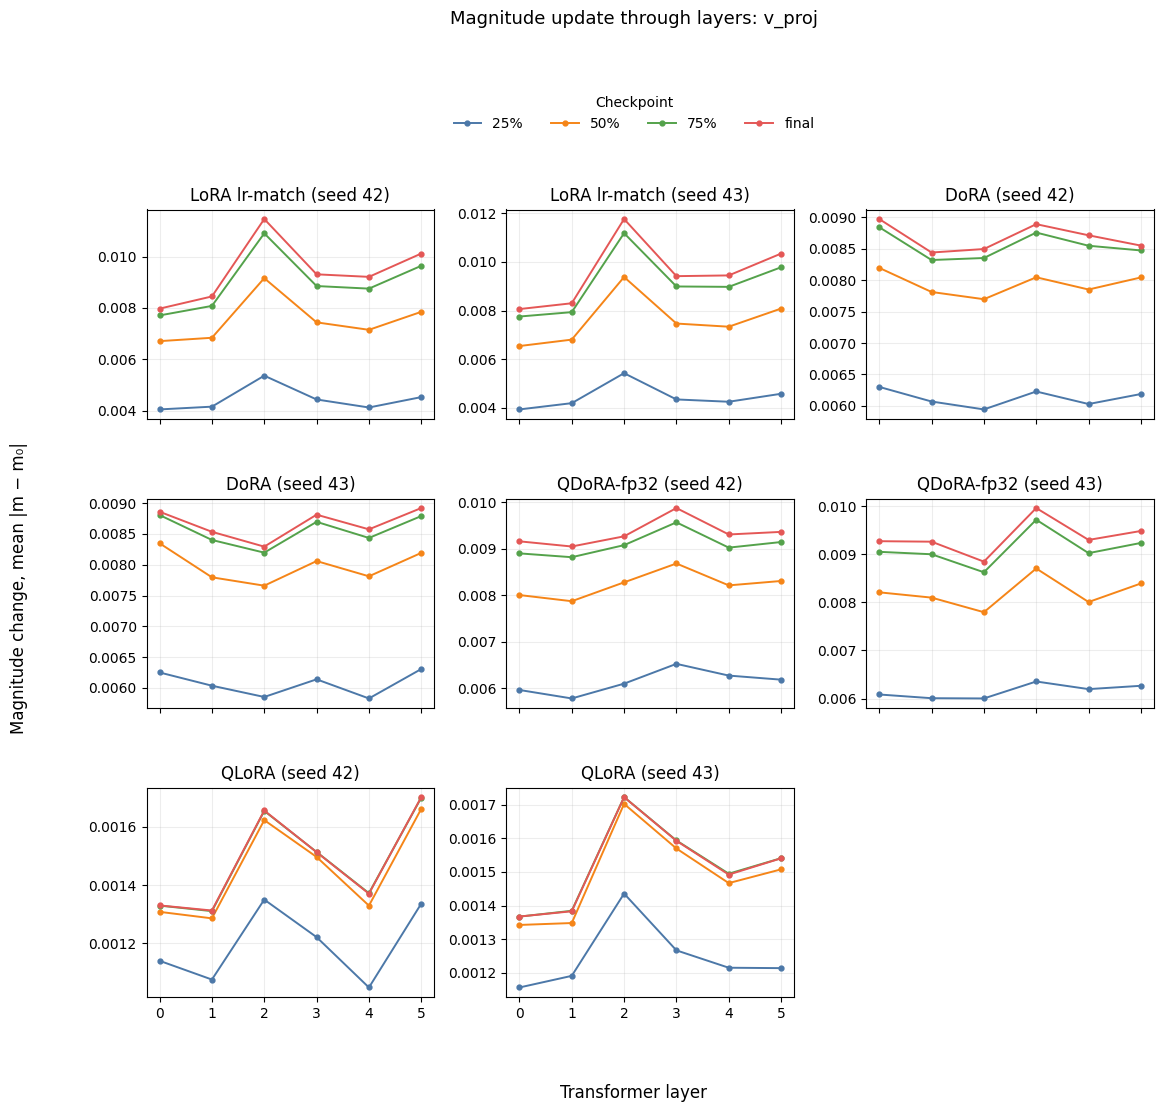

Exported: outputs/mech_delta_m_by_layer_v_proj.pdf


In [11]:
CHECKPOINT_COLORS = {
    0.25: "#4C78A8", 0.50: "#F58518", 0.75: "#54A24B", 1.00: "#E45756"
}

for module in PAPER_TARGET_MODULES:
    fig, axes = plt.subplots(
        NROWS, NCOLS, figsize=(13, 3.5 * NROWS), squeeze=False,
        sharex=True, sharey=False,
    )

    for axis, run_id in zip(axes.flat, plotted_runs):
        subset = paper_df[
            (paper_df["run_id"] == run_id)
            & (paper_df["target_module"] == module)
        ]
        for checkpoint, checkpoint_subset in subset.groupby("checkpoint_fraction"):
            checkpoint_subset = checkpoint_subset.sort_values("layer")
            axis.plot(
                checkpoint_subset["layer"],
                checkpoint_subset[PAPER_M_METRIC],
                color=CHECKPOINT_COLORS[float(checkpoint)],
                marker="o",
                linewidth=1.4,
                markersize=3.5,
                label=("final" if checkpoint == 1.0 else f"{checkpoint:.0%}"),
            )
        axis.set_title(display_name(run_id))
        axis.set_xticks(LAYERS)
        axis.grid(alpha=0.22)

    for axis in axes.flat[len(plotted_runs):]:
        axis.set_visible(False)

    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.suptitle(f"Magnitude update through layers: {module}", y=1.05, fontsize=13)
    fig.legend(handles, labels, title="Checkpoint", loc="upper center",
               bbox_to_anchor=(0.5, 0.98), ncol=4, frameon=False)
    fig.supxlabel("Transformer layer")
    fig.supylabel("Magnitude change, mean |m − m₀|")
    fig.subplots_adjust(top=0.86, hspace=0.38, wspace=0.25)

    output_path = OUTPUT_DIR / f"mech_delta_m_by_layer_{module}.pdf"
    fig.savefig(output_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Exported: {output_path}")

## 9. Low-rank coefficient-update slopes through layers

For each physical run, module, and layer, this view plots the slope of
$\lVert sBA \rVert_F/\lVert W_0 \rVert_F$ against checkpoint fraction. It
complements the ΔM–ΔD regression by showing where low-rank coefficient
updates accumulate most rapidly during training.

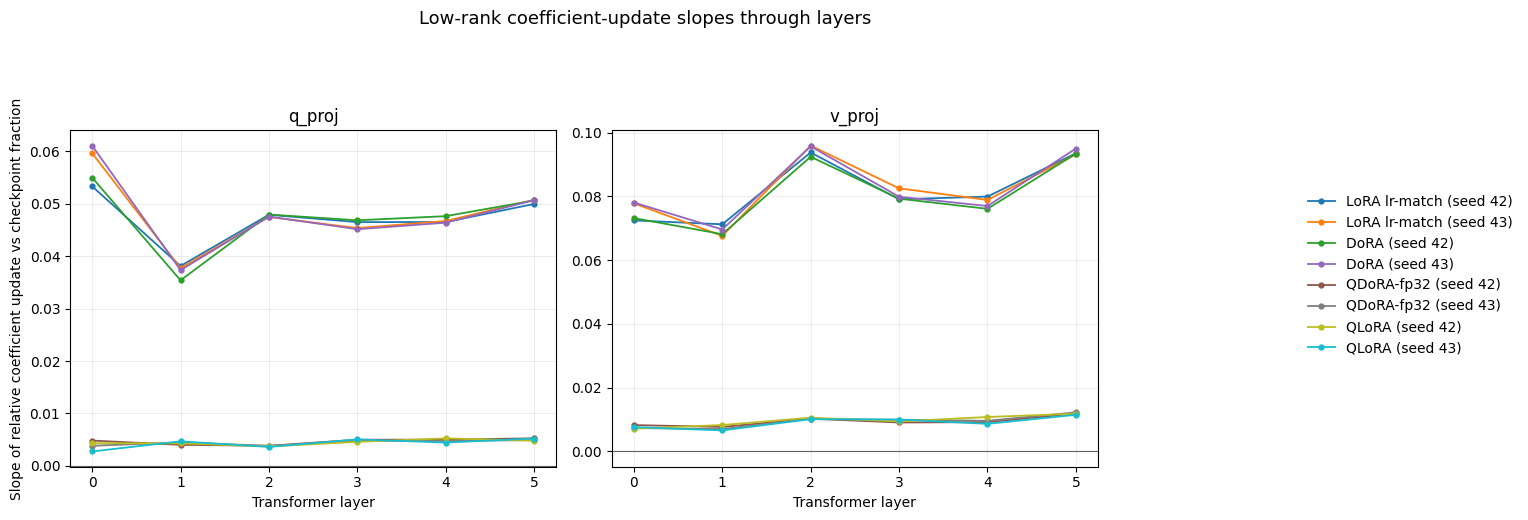

Exported: outputs/mech_coefficient_update_slopes_by_layer.pdf


In [12]:
coefficient_slopes = regression_df[
    (regression_df["relationship"] == "coefficient_update_vs_checkpoint")
    & (regression_df["target_module"].isin(PAPER_TARGET_MODULES))
].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=False)
colors = plt.cm.tab10(np.linspace(0, 1, len(RUN_ORDER)))
for axis, module in zip(axes, PAPER_TARGET_MODULES):
    module_data = coefficient_slopes[coefficient_slopes["target_module"] == module]
    for color, run_id in zip(colors, RUN_ORDER):
        subset = module_data[module_data["run_id"] == run_id].sort_values("layer")
        axis.plot(
            subset["layer"], subset["slope"], marker="o", markersize=3.5,
            linewidth=1.3, color=color, label=display_name(run_id),
        )
    axis.axhline(0, color="black", linewidth=0.8, alpha=0.6)
    axis.set_title(module)
    axis.set_xticks(LAYERS)
    axis.set_xlabel("Transformer layer")
    axis.grid(alpha=0.22)

axes[0].set_ylabel("Slope of relative coefficient update vs checkpoint fraction")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)
fig.suptitle("Low-rank coefficient-update slopes through layers", y=1.03, fontsize=13)
fig.tight_layout(rect=[0, 0, 0.86, 0.93])

coefficient_figure = OUTPUT_DIR / "mech_coefficient_update_slopes_by_layer.pdf"
fig.savefig(coefficient_figure, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Exported: {coefficient_figure}")

## 10. Quantization decomposition

In [13]:
quantized_rows = weight_df[weight_df["quantized_base"]].copy()
quantization_columns = [
    "quant_delta_magnitude_paper", "delta_magnitude_paper",
    "total_delta_magnitude_paper", "quant_delta_direction",
    "delta_direction", "total_delta_direction",
]

quantization_summary = (
    quantized_rows
    .groupby(["run_id", "run", "method", "seed", "target_module"], dropna=False)
    [quantization_columns]
    .mean()
    .reset_index()
    .rename(columns={
        "quant_delta_magnitude_paper": "dM_quantization",
        "delta_magnitude_paper": "dM_adapter",
        "total_delta_magnitude_paper": "dM_total",
        "quant_delta_direction": "dD_quantization",
        "delta_direction": "dD_adapter",
        "total_delta_direction": "dD_total",
    })
)
quantization_summary["dM_quant_share"] = (
    quantization_summary["dM_quantization"]
    / quantization_summary["dM_total"].clip(lower=EPS)
)
quantization_summary["dD_quant_share"] = (
    quantization_summary["dD_quantization"]
    / quantization_summary["dD_total"].clip(lower=EPS)
)
quantization_summary.to_csv(
    OUTPUT_DIR / "mech_quantization_effects.csv", index=False
)

display(quantization_summary.round(5))
print(f"Exported: {OUTPUT_DIR / 'mech_quantization_effects.csv'}")

,run_id,run,method,seed,target_module,dM_quantization,dM_adapter,dM_total,dD_quantization,dD_adapter,dD_total,dM_quant_share,dD_quant_share
0,qdora-seed42-fp32,QDoRA-fp32 (seed 42),QDoRA-fp32,42,down_proj,0.00122,0.00896,0.00901,0.00432,0.00177,0.00609,0.13486,0.71037
1,qdora-seed42-fp32,QDoRA-fp32 (seed 42),QDoRA-fp32,42,k_proj,0.00333,0.00713,0.00804,0.00470,0.00064,0.00534,0.41419,0.88060
2,qdora-seed42-fp32,QDoRA-fp32 (seed 42),QDoRA-fp32,42,q_proj,0.00214,0.00750,0.00791,0.00458,0.00111,0.00569,0.27017,0.80567
3,qdora-seed42-fp32,QDoRA-fp32 (seed 42),QDoRA-fp32,42,up_proj,0.00115,0.00889,0.00896,0.00431,0.00248,0.00678,0.12859,0.63547
4,qdora-seed42-fp32,QDoRA-fp32 (seed 42),QDoRA-fp32,42,v_proj,0.00081,0.00820,0.00822,0.00442,0.00341,0.00782,0.09890,0.56543
5,qdora-seed43-fp32,QDoRA-fp32 (seed 43),QDoRA-fp32,43,down_proj,0.00122,0.00904,0.00909,0.00432,0.00179,0.00611,0.13367,0.70795
6,qdora-seed43-fp32,QDoRA-fp32 (seed 43),QDoRA-fp32,43,k_proj,0.00333,0.00715,0.00801,0.00470,0.00066,0.00536,0.41567,0.87750
7,qdora-seed43-fp32,QDoRA-fp32 (seed 43),QDoRA-fp32,43,q_proj,0.00214,0.00751,0.00791,0.00458,0.00112,0.00570,0.27020,0.80367
8,qdora-seed43-fp32,QDoRA-fp32 (seed 43),QDoRA-fp32,43,up_proj,0.00115,0.00888,0.00895,0.00431,0.00246,0.00676,0.12879,0.63721
9,qdora-seed43-fp32,QDoRA-fp32 (seed 43),QDoRA-fp32,43,v_proj,0.00081,0.00821,0.00823,0.00442,0.00331,0.00772,0.09874,0.57306


Exported: outputs/mech_quantization_effects.csv


## 11. Layer-0 sensitivity

This supplementary table shows whether the primary ΔM–ΔD result is driven
by layer 0. It contains only Q/V projections and the paper ΔM definition.

In [14]:
sensitivity_rows = []
for (run_id, run_name, method, seed, module), subset in paper_df.groupby(
    ["run_id", "run", "method", "seed", "target_module"], dropna=False
):
    slope_all, intercept_all, corr_all, r2_all, n_all = fit_relation(
        subset, "delta_direction", PAPER_M_METRIC
    )
    without_layer0 = subset[subset["layer"] != 0]
    slope_excl0, intercept_excl0, corr_excl0, r2_excl0, n_excl0 = fit_relation(
        without_layer0, "delta_direction", PAPER_M_METRIC
    )
    sensitivity_rows.append({
        "run_id": run_id,
        "run": run_name,
        "method": method,
        "seed": seed,
        "target_module": module,
        "slope_all_layers": slope_all,
        "correlation_all_layers": corr_all,
        "r_squared_all_layers": r2_all,
        "n_all_layers": n_all,
        "slope_excluding_layer0": slope_excl0,
        "correlation_excluding_layer0": corr_excl0,
        "r_squared_excluding_layer0": r2_excl0,
        "n_excluding_layer0": n_excl0,
    })

layer0_sensitivity = pd.DataFrame(sensitivity_rows)
layer0_sensitivity.to_csv(
    OUTPUT_DIR / "mech_layer0_sensitivity.csv", index=False
)
display(layer0_sensitivity.round(5))
print(f"Exported: {OUTPUT_DIR / 'mech_layer0_sensitivity.csv'}")

,run_id,run,method,seed,target_module,slope_all_layers,correlation_all_layers,r_squared_all_layers,n_all_layers,slope_excluding_layer0,correlation_excluding_layer0,r_squared_excluding_layer0,n_excluding_layer0
0,dora-seed42,DoRA (seed 42),DoRA,42,q_proj,0.27119,0.74484,0.55479,24,0.50437,0.94728,0.89734,20
1,dora-seed42,DoRA (seed 42),DoRA,42,v_proj,0.12257,0.68974,0.47573,24,0.11449,0.68798,0.47332,20
2,dora-seed43,DoRA (seed 43),DoRA,43,q_proj,0.22712,0.67521,0.45592,24,0.49079,0.89902,0.80823,20
3,dora-seed43,DoRA (seed 43),DoRA,43,v_proj,0.12211,0.68418,0.46810,24,0.11342,0.67329,0.45332,20
4,lora-match-seed42,LoRA lr-match (seed 42),LoRA lr-match,42,q_proj,0.78513,0.99407,0.98817,24,0.79027,0.98050,0.96138,20
5,lora-match-seed42,LoRA lr-match (seed 42),LoRA lr-match,42,v_proj,0.36265,0.95256,0.90736,24,0.35323,0.95295,0.90811,20
6,lora-match-seed43,LoRA lr-match (seed 43),LoRA lr-match,43,q_proj,0.75710,0.99299,0.98603,24,0.79183,0.97925,0.95894,20
7,lora-match-seed43,LoRA lr-match (seed 43),LoRA lr-match,43,v_proj,0.36314,0.95594,0.91382,24,0.35298,0.95547,0.91292,20
8,qdora-seed42-fp32,QDoRA-fp32 (seed 42),QDoRA-fp32,42,q_proj,1.30468,0.29349,0.08613,24,4.20235,0.48979,0.23989,20
9,qdora-seed42-fp32,QDoRA-fp32 (seed 42),QDoRA-fp32,42,v_proj,0.66372,0.37267,0.13889,24,0.57918,0.35234,0.12415,20


Exported: outputs/mech_layer0_sensitivity.csv


## 12. Export manifest

All retained tables and figures use the `mech_` prefix. The CSV files are
tidy, full-precision analysis tables; figures are vector PDFs suitable for
inclusion in a paper. These are the only files this notebook writes: the
adapters and base weights it read stay on the Hub.

In [15]:
exported_artifacts = sorted(
    path.name for path in OUTPUT_DIR.iterdir()
    if path.is_file() and path.name.startswith("mech_")
)
display(pd.DataFrame({"artifact": exported_artifacts}))

,artifact
0,mech_coefficient_update_slopes_by_layer.pdf
1,mech_delta_m_by_layer_q_proj.pdf
2,mech_delta_m_by_layer_v_proj.pdf
3,mech_delta_m_vs_delta_d_q_proj.pdf
4,mech_delta_m_vs_delta_d_v_proj.pdf
5,mech_layer0_sensitivity.csv
6,mech_layer_metrics.csv
7,mech_quantization_effects.csv
8,mech_regression_results.csv
